# Bvarta Bahari — 04. Rekomendasi Rute Baru

Mengusulkan rute laut baru yang masuk akal dari sisi permintaan dan operasional, lengkap dengan
estimasi biaya operasional dan pendapatan. Tiga komponen estimasi dibangun terpisah dan transparan:
jarak tempuh laut, permintaan, lalu ekonomi (revenue vs biaya).

### Metode & asumsi
- **Jarak laut** rute baru tidak tersedia, jadi dikalibrasi: faktor koreksi = jarak laut aktual /
  jarak garis lurus (haversine) dari rute eksisting, lalu diterapkan ke pasangan pelabuhan baru.
- **Permintaan** diturunkan dari `mobility_daily` (jumlah pelaku perjalanan antar-region, semua
  moda) dikali *capture rate* (porsi yang memakai laut). Capture rate dikalibrasi dari rute
  eksisting; karena sangat bervariasi, estimasi disajikan sebagai rentang (pesimis/tengah/optimis),
  bukan angka tunggal. Ini keterbatasan terbesar dan ditandai jujur.
- **Biaya** memakai model bottom-up (bahan bakar, kru, jasa pelabuhan, perawatan) dengan konstanta
  dikalibrasi dari opex eksisting; akurasinya ±~15% untuk rute aktif.
- **Pendapatan** = permintaan × tarif, tarif dikalibrasi per-nm dari harga rute eksisting.
- **Batasan domain dijaga:** kapal yang diusulkan dicek draft vs alur pelabuhan dan ketersediaan.

In [1]:
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
DATA="../data/"
pd.set_option("display.width",170); pd.set_option("display.max_columns",40)
plt.rcParams["figure.figsize"]=(11,3.6)

ports=pd.read_csv(DATA+"ports.csv").set_index("port_id")
routes=pd.read_csv(DATA+"routes_existing.csv")
fleet=pd.read_csv(DATA+"fleet.csv").set_index("ship_id")
orders=pd.read_csv(DATA+"orders_history_daily.csv",parse_dates=["date"])
prices=pd.read_csv(DATA+"route_prices.csv")
opex=pd.read_csv(DATA+"route_opex_monthly.csv")
mob=pd.read_csv(DATA+"mobility_daily.csv",parse_dates=["date"])
print("loaded | 19 ports |",len(routes),"rute eksisting | 35 kapal")

loaded | 19 ports | 16 rute eksisting | 35 kapal


## 1. Kalibrasi jarak tempuh laut

Jarak laut bukan garis lurus. Untuk rute baru yang belum punya data jarak, kita kalibrasi faktor
koreksi dari rute eksisting: rasio antara jarak laut tercatat (`distance_nm`) dan jarak garis lurus
(haversine) antar pelabuhannya.

In [2]:
def haversine_nm(a,b):
    la1,lo1,la2,lo2=map(np.radians,[ports.loc[a,"lat"],ports.loc[a,"lon"],ports.loc[b,"lat"],ports.loc[b,"lon"]])
    h=np.sin((la2-la1)/2)**2+np.cos(la1)*np.cos(la2)*np.sin((lo2-lo1)/2)**2
    return 2*6371*np.arcsin(np.sqrt(h))/1.852

routes["hav_nm"]=[haversine_nm(o,d) for o,d in zip(routes.origin_port_id,routes.dest_port_id)]
routes["ratio"]=routes.distance_nm/routes.hav_nm
FACTOR=routes.ratio.median()
print(f"Faktor koreksi jarak laut: median={FACTOR:.3f}, mean={routes.ratio.mean():.3f}, std={routes.ratio.std():.3f}")
print(f"Rentang rasio: {routes.ratio.min():.2f} - {routes.ratio.max():.2f}  (n={len(routes)} rute)")
routes[["route_id","origin_port_id","dest_port_id","distance_nm","hav_nm","ratio"]].round(2)

Faktor koreksi jarak laut: median=1.272, mean=1.275, std=0.103
Rentang rasio: 1.13 - 1.43  (n=16 rute)


,route_id,origin_port_id,dest_port_id,distance_nm,hav_nm,ratio
0,R01,MRK,BKH,18.3,15.65,1.17
1,R02,KTP,GLM,4.2,2.93,1.43
2,R03,PDB,BNO,31.5,22.05,1.43
3,R04,PRK,SMG,277.2,217.55,1.27
4,R05,SMG,SBY,155.3,137.93,1.13
5,R06,PRK,SBY,494.7,354.93,1.39
6,R07,SBY,BNO,208.6,174.29,1.20
7,R08,CBN,SMG,147.3,111.56,1.32
8,R09,PJG,BBR,202.5,153.49,1.32
9,R10,BBR,BTM,313.7,252.25,1.24


Rasio terkumpul rapat (median 1.27, std 0.10), jadi satu faktor koreksi cukup defensible untuk
estimasi perencanaan. Jarak laut rute baru = haversine × 1.27.

## 2. Skrining koridor & kalibrasi capture rate

Koridor kandidat dipilih dari pasangan region dengan mobilitas tinggi yang belum punya rute laut
langsung. Sebelum mengestimasi permintaan, kita kalibrasi dulu seberapa besar porsi mobilitas yang
benar-benar terangkut laut (capture rate) pada rute eksisting.

In [3]:
# capture rate eksisting = tiket harian / mobilitas harian pasangan region
tk=orders[orders.trips>0].groupby("route_id").tickets_sold.mean()
mob["pair"]=mob.apply(lambda r: tuple(sorted([r.origin_region,r.dest_region])),axis=1)
mm=mob.groupby("pair").estimated_travelers.mean()
def regpair_of(o,d): return tuple(sorted([ports.loc[o,"region"],ports.loc[d,"region"]]))
cap=[]
for _,r in routes.iterrows():
    rp=regpair_of(r.origin_port_id,r.dest_port_id)
    if rp in mm.index and rp[0]!=rp[1]:
        cap.append(dict(route=r.route_id,regpair=rp,tick_day=round(tk[r.route_id]),
                        mob_day=round(mm[rp]),capture=round(tk[r.route_id]/mm[rp],3)))
capdf=pd.DataFrame(cap)
core=capdf[capdf.capture<5].capture   # buang outlier penyeberangan dominan (R01)
print("Capture rate eksisting (porsi mobilitas terangkut laut):")
print(f"  median(inti, tanpa outlier)={core.median():.2f} | rentang inti {core.min():.2f}-{core.max():.2f}")
print(f"  outlier R01 (Merak-Bakauheni) = {capdf.capture.max():.1f}  -> penyeberangan dominan, volume jauh di atas estimasi mobilitas")
capdf.sort_values("capture")

Capture rate eksisting (porsi mobilitas terangkut laut):
  median(inti, tanpa outlier)=0.53 | rentang inti 0.05-1.75
  outlier R01 (Merak-Bakauheni) = 12.6  -> penyeberangan dominan, volume jauh di atas estimasi mobilitas


,route,regpair,tick_day,mob_day,capture
11,R14,"(Jakarta, Lampung)",95,1944,0.049
3,R05,"(Jateng, Jatim)",187,947,0.197
5,R07,"(Bali, Jatim)",431,1330,0.324
6,R08,"(Cirebon, Jateng)",232,676,0.343
4,R06,"(Jakarta, Jatim)",371,887,0.418
10,R13,"(Kepri, Sumut)",88,167,0.526
2,R04,"(Jakarta, Jateng)",894,1553,0.576
9,R12,"(Kepri, Riau)",214,226,0.950
7,R09,"(Lampung, Sumsel)",514,359,1.432
1,R02,"(Bali, Jatim)",2143,1330,1.612


**Pembacaan penting (kejujuran metodologi):** capture rate sangat bervariasi (0.05 sampai
>12). R01 (Merak–Bakauheni) jauh di atas 1 karena ini penyeberangan utama Jawa–Sumatera yang
volumenya melampaui estimasi mobilitas semua-moda; sebaliknya R14 (Jakarta–Lampung) hanya 0.05
karena kalah dari penyeberangan R01 dan jalur darat. Artinya **mobilitas adalah penanda potensi
yang lemah untuk permintaan laut absolut**. Konsekuensinya estimasi permintaan rute baru dibuat
sebagai rentang lebar dengan capture pesimis/tengah/optimis = 0.15 / 0.40 / 0.80, bukan titik.

## 3. Koridor kandidat & estimasi permintaan

Koridor dipilih yang mobilitasnya tinggi tetapi belum terlayani rute laut langsung, dan secara
geografi masuk akal lewat laut. Pasangan pesisir jarak sangat pendek yang didominasi jalur darat
(mis. Jakarta–Cirebon, Banten–Jakarta) dikecualikan karena laut sulit bersaing.

In [4]:
served=set(tuple(sorted([o,d])) for o,d in zip(routes.origin_port_id,routes.dest_port_id))
served_reg=set(regpair_of(o,d) for o,d in zip(routes.origin_port_id,routes.dest_port_id))
# kandidat kurасi: (origin_port, dest_port, alasan) - underserved + mobilitas tinggi + feasible laut
candidates=[
    ("PRK","BBR","Jakarta-Palembang (Sumsel): mobilitas tinggi, tak ada rute laut langsung"),
    ("SMG","PJG","Jateng-Lampung: jembatani Jawa Tengah ke gerbang Sumatera"),
    ("PRK","BNO","Jakarta-Bali: koridor premium jarak jauh"),
    ("SBY","BBR","Jatim-Sumsel: hubungkan Jawa Timur ke Sumatera selatan"),
]
rows=[]
CAP={"pesimis":0.15,"tengah":0.40,"optimis":0.80}
for o,d,alasan in candidates:
    rp=regpair_of(o,d); mobd=mm.get(rp,np.nan)
    dist=round(haversine_nm(o,d)*FACTOR,1)
    pax={k:round(mobd*v) for k,v in CAP.items()}
    rows.append(dict(rute=f"{o}-{d}",regpair=f"{rp[0]}-{rp[1]}",mob_day=round(mobd),
        dist_nm=dist, pax_pesimis=pax["pesimis"],pax_tengah=pax["tengah"],pax_optimis=pax["optimis"],
        sudah_dilayani=(tuple(sorted([o,d])) in served), alasan=alasan))
cand=pd.DataFrame(rows)
print("Kandidat rute baru + estimasi permintaan harian (pax) per skenario capture:")
cand[["rute","regpair","mob_day","dist_nm","pax_pesimis","pax_tengah","pax_optimis"]]

Kandidat rute baru + estimasi permintaan harian (pax) per skenario capture:


,rute,regpair,mob_day,dist_nm,pax_pesimis,pax_tengah,pax_optimis
0,PRK-BBR,Jakarta-Sumsel,1148,288.2,172,459,918
1,SMG-PJG,Jateng-Lampung,713,403.8,107,285,571
2,PRK-BNO,Bali-Jakarta,423,662.3,63,169,338
3,SBY-BBR,Jatim-Sumsel,184,686.1,28,74,147


## 4. Estimasi biaya operasional & pendapatan

Biaya memakai model bottom-up yang dikalibrasi di analisis evaluasi rute; pendapatan memakai tarif
per-nm dari rute eksisting. Frekuensi dipilih agar kapasitas kira-kira menutup permintaan skenario
tengah pada keterisian target 70%. Kapal diusulkan dari armada yang (a) draft-nya muat di kedua
pelabuhan, (b) statusnya tersedia, dan (c) **batas gelombangnya memadai** untuk perairan rute
(estimasi pembatalan <= 10%). Pendapatan dan biaya variabel didiskon dengan porsi hari berlayar
(1 - estimasi pembatalan), karena rute laut terbuka di sini batal ~40-55% hari jika kapalnya salah
kelas.

In [5]:
# tarif blended per-nm dari eksisting
def blend_price(g):
    p=g.set_index("ticket_class").price_idr
    return (.70*p["Ekonomi"]+.25*p["Bisnis"]+.05*p["Kabin"]) if "Kabin" in p.index else (.80*p["Ekonomi"]+.20*p["Bisnis"])
pb=prices.groupby("route_id").apply(blend_price).rename("price_blend")
rd=routes.set_index("route_id")
fare_per_nm=(pb/rd.distance_nm).median()
print(f"Tarif blended per nm (median eksisting): {fare_per_nm:,.0f} IDR/nm")

# gelombang per perairan -> estimasi pembatalan utk kombinasi kapal/rute.
# Pada rute eksisting, rate pembatalan = fraksi hari gelombang > batas operasi kapal (terbukti
# korelasi ~1.0 di analisis penugasan armada), jadi pemilihan kelas kapal harus sadar gelombang.
ww=pd.read_csv(DATA+"weather_wind_wave_daily.csv"); ww["date"]=pd.to_datetime(ww["date"],format="%d/%m/%Y")
waves={s:g["wave_height_m"].values for s,g in ww.groupby("sea_area")}
def exp_cancel(ship,o,d):
    lim=fleet.loc[ship,"max_operating_wave_m"]
    so=ports.loc[o,"sea_area"]; sd=ports.loc[d,"sea_area"]
    return float(max((waves[so]>lim).mean(),(waves[sd]>lim).mean()))

FUEL=13500; PORT=1_500_000; MAINT=0.015; TARGET_LF=0.70
def pick_ship(o,d,need_cap):
    # feasible: draft muat alur + tersedia + batas gelombang memadai (estimasi pembatalan <= 10%)
    dmax=min(ports.loc[o,"max_draft_m"],ports.loc[d,"max_draft_m"])
    base=fleet[(fleet.draft_m<=dmax)&(fleet.status!="maintenance")].copy()
    base["cancel"]=[exp_cancel(s,o,d) for s in base.index]
    reliable=base[base.cancel<=0.10]
    pool=reliable if len(reliable) else base.sort_values("cancel").head(5)
    big=pool[pool.pax_capacity>=need_cap]
    cand=big if len(big) else pool
    return cand.sort_values(["cancel","pax_capacity"]).index[0]

def economics(o,d,mobd):
    dist=haversine_nm(o,d)*FACTOR
    seats_needed=mobd*0.40/TARGET_LF                  # kapasitas utk skenario tengah
    ship=pick_ship(o,d,seats_needed); sh=fleet.loc[ship]
    cancel=exp_cancel(ship,o,d); sail=1-cancel        # porsi hari benar-benar berlayar
    trips_day=max(1,int(np.ceil(seats_needed/sh.pax_capacity)))
    dur=dist/sh.service_speed_knots
    trips_mo=trips_day*30*sail                          # trip batal tak jalan -> hemat BBM & jasa pelabuhan
    fuel=trips_mo*dur*sh.fuel_consumption_lph*FUEL
    crew=sh.daily_crew_cost_idr*30                      # kru tetap dibayar walau batal
    port=trips_mo*2*PORT
    opx=(fuel+crew+port)*(1+MAINT)
    fare=fare_per_nm*dist
    out={}
    for k,v in {"pesimis":0.15,"tengah":0.40,"optimis":0.80}.items():
        rev=mobd*v*30*sail*fare                          # pendapatan hanya pada hari berlayar
        out[k]=(rev-opx)/1e6
    return dict(dist_nm=round(dist,1),kapal=ship,tipe=sh.ship_type,kap_pax=int(sh.pax_capacity),
        batal=round(cancel,2),trips_hari=trips_day,fare_blended=round(fare),opex_jt=round(opx/1e6),
        margin_pesimis=round(out["pesimis"]),margin_tengah=round(out["tengah"]),margin_optimis=round(out["optimis"]))

econ=[]
for o,d,_ in candidates:
    e=economics(o,d,mm.get(regpair_of(o,d))); e["rute"]=f"{o}-{d}"; econ.append(e)
E=pd.DataFrame(econ).set_index("rute")
print("Estimasi ekonomi bulanan (juta IDR), kapal diusulkan + cek draft & gelombang:")
E[["dist_nm","kapal","tipe","kap_pax","batal","trips_hari","fare_blended","opex_jt",
   "margin_pesimis","margin_tengah","margin_optimis"]]

Tarif blended per nm (median eksisting): 2,231 IDR/nm


Estimasi ekonomi bulanan (juta IDR), kapal diusulkan + cek draft & gelombang:


,dist_nm,kapal,tipe,kap_pax,batal,trips_hari,fare_blended,opex_jt,margin_pesimis,margin_tengah,margin_optimis
rute,,,,,,,,,,,
PRK-BBR,288.2,KM-10,Passenger Ship,777,0.00,1,642979,4605,-1298,4213,13031
SMG-PJG,403.8,KM-24,Passenger Ship,565,0.02,1,900868,4415,-1581,3142,10699
PRK-BNO,662.3,KM-24,Passenger Ship,565,0.00,1,1477428,7135,-4339,322,7779
SBY-BBR,686.1,KM-24,Passenger Ship,565,0.00,1,1530576,7399,-6135,-4028,-657


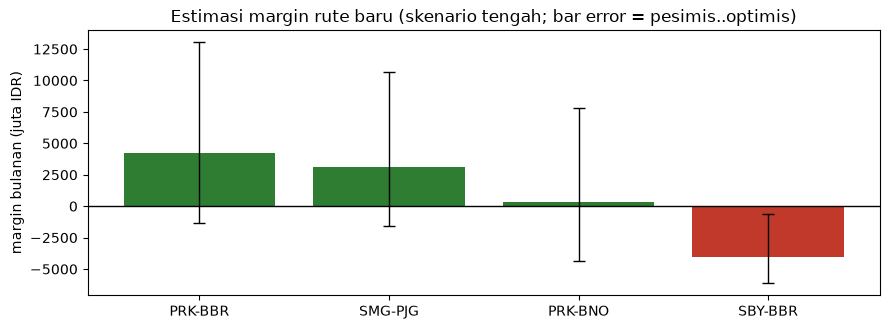

,margin_pesimis,margin_tengah,margin_optimis
rute,,,
PRK-BBR,-1298,4213,13031
SMG-PJG,-1581,3142,10699
PRK-BNO,-4339,322,7779
SBY-BBR,-6135,-4028,-657


In [6]:
# Ranking by margin skenario tengah, dengan band ketidakpastian
rank=E.sort_values("margin_tengah",ascending=False)
fig,ax=plt.subplots(figsize=(9,3.4))
x=np.arange(len(rank))
ax.bar(x,rank.margin_tengah,color=["#2e7d32" if m>0 else "#c0392b" for m in rank.margin_tengah])
ax.errorbar(x,rank.margin_tengah,yerr=[rank.margin_tengah-rank.margin_pesimis,rank.margin_optimis-rank.margin_tengah],
            fmt="none",ecolor="k",capsize=4,lw=1)
ax.axhline(0,color="k",lw=1); ax.set_xticks(x); ax.set_xticklabels(rank.index)
ax.set_ylabel("margin bulanan (juta IDR)"); ax.set_title("Estimasi margin rute baru (skenario tengah; bar error = pesimis..optimis)")
plt.tight_layout(); plt.show()
rank[["margin_pesimis","margin_tengah","margin_optimis"]]

**Pembacaan:** ranking digerakkan oleh jarak (biaya), mobilitas (potensi), dan kecocokan kelas
kapal dengan gelombang (keandalan). Yang menonjol adalah koridor mobilitas tinggi dengan jarak
menengah; koridor jarak sangat jauh terbebani biaya bahan bakar walau permintaannya ada. Perhatikan
lebar band: pada skenario pesimis sebagian kandidat rugi, jadi rekomendasi bersifat kondisional pada
capture rate yang terealisasi, bukan kepastian. Semua kapal yang diusulkan lolos cek draft dan
dipilih berbatas-gelombang memadai (kolom `batal` rendah), sehingga estimasi pendapatan sudah
memperhitungkan keandalan berlayar.

## 5. Ringkasan & keterbatasan

**Rekomendasi rute baru** (prioritas pada margin skenario tengah yang positif dan band yang tidak
jatuh terlalu dalam ke rugi): lihat tabel ranking. Kandidat teratas layak diuji lewat *pilot*
frekuensi rendah dulu untuk memvalidasi capture rate sebelum komitmen armada penuh.

**Keterbatasan (terbesar di permintaan):**
- **Estimasi permintaan lemah.** Mobilitas semua-moda buruk memprediksi permintaan laut absolut
  (capture rate 0.05–12 pada rute eksisting). Estimasi disajikan sebagai rentang lebar; angka pasti
  butuh data perpindahan moda atau survei asal-tujuan. Inilah alasan rekomendasi pilot, bukan
  langsung skala penuh.
- Faktor koreksi jarak tunggal (1.27) mengabaikan variasi alur per perairan; untuk rute spesifik
  bisa dipertajam dengan rute analog di perairan yang sama.
- Model biaya akurat ±~15% untuk rute aktif tetapi *under-estimate* rute frekuensi sangat rendah
  (biaya tetap menyebar ke sedikit trip); kandidat sebaiknya dijalankan pada frekuensi memadai.
- Penugasan kapal di sini mempertimbangkan draft, ketersediaan, dan batas gelombang (lewat estimasi
  pembatalan); bentrok jadwal harian dan rotasi armada penuh dibahas di analisis penugasan armada.
- Estimasi pendapatan memakai tarif per-nm rata-rata; tarif aktual bisa disesuaikan per koridor
  (daya beli, persaingan).